# sourcing the data

In [97]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import math
import json 

from plots.utils import load_sledge_data, prepare_step_data
plt.style.use('./plots/latex_style.mplstyle')

benches = ["ROVER", 'Hydra', 'Alive', 'Cadence']

RESULTS_DIR = Path("../results")
RESULTS_DIR_ALT = Path("../benchmarks/results")

FIGURES_PATH = RESULTS_DIR / 'plots'

TIMEOUT = 60_000 # timeout in milliseconds

os.makedirs(FIGURES_PATH, exist_ok=True)

parabit = {}
mirabelle = {}
pbv = {}

pbv["Alive"] = pd.read_csv(f'{RESULTS_DIR_ALT}/solver/alive_smt2/results.csv')
pbv["Hydra"] = pd.read_csv(f'{RESULTS_DIR_ALT}/solver/hydra_smt2/results.csv')
pbv["Cadence"] = pd.read_csv(f'{RESULTS_DIR_ALT}/solver/Cadence_smt2/summary.csv')
pbv["ROVER"] = pd.read_csv(f'{RESULTS_DIR_ALT}/solver/rover_smt2/summary.csv')

for bench in benches:
    parabit[bench] = pd.read_csv(f'{RESULTS_DIR}/parabit/{bench}/results.csv')
    parabit[bench]['time_taken'] = parabit[bench]['time_taken'] * 1000 # convert seconds to milliseconds
    parabit[bench]['file'] = parabit[bench]['file'].str.replace('.bwlang', '', regex=False) # remove file extension
    if bench == 'Hydra':
        parabit[bench]['file'] = parabit[bench]['file'].str.replace('hydra_', '', regex=False) # remove file extension
    parabit[bench].set_index('file')

    mirabelle[bench] = {}
    mirabelle[bench]["lemma"] =   load_sledge_data(RESULTS_DIR / "mirabelle" / "lemma"   / bench / "parsed.json")
    mirabelle[bench]["nolemma"] = load_sledge_data(RESULTS_DIR / "mirabelle" / "nolemma" / bench / "parsed.json")
    if bench == 'Hydra':
        mirabelle[bench]["lemma"]['name'] = mirabelle[bench]["lemma"]['name'].str.replace('hydra_', '', regex=False) # remove file extension
        mirabelle[bench]["nolemma"]['name'] = mirabelle[bench]["nolemma"]['name'].str.replace('hydra_', '', regex=False) # remove file extension
    
    # remove problems that took longer than the timeout
    mirabelle[bench]["lemma"] = mirabelle[bench]["lemma"].where(mirabelle[bench]["lemma"]['time'] <= TIMEOUT)
    mirabelle[bench]["nolemma"] = mirabelle[bench]["nolemma"].where(mirabelle[bench]["nolemma"]['time'] <= TIMEOUT)
    mirabelle[bench]["lemma"].set_index('name')
    mirabelle[bench]["nolemma"].set_index('name')

    pbv[bench]['file'] = pbv[bench]['file'].str.replace('.smt2', '', regex=False) # remove file extension
    pbv[bench].set_index('file')

pbv, parabit, mirabelle

({'Alive':                      file   result       time last_log_line
  0    AddSub_1165_values_0    unsat   0.006301         unsat
  1    AddSub_1560_values_0    unsat   0.024585         unsat
  2    AddSub_1564_values_0    unsat   0.104972         unsat
  3    AddSub_1098_values_0    unsat   0.013133         unsat
  4    AddSub_1574_values_0    unsat   0.008317         unsat
  ..                    ...      ...        ...           ...
  195   Select_727_values_0  timeout  60.000000       TIMEOUT
  196   Select_740_values_0  timeout  60.000000       TIMEOUT
  197   Select_741_values_0  timeout  60.000000       TIMEOUT
  198   Select_746_values_0  timeout  60.000000       TIMEOUT
  199   Select_747_values_0  timeout  60.000000       TIMEOUT
  
  [200 rows x 4 columns],
  'Hydra':          file   result       time last_log_line
  0    opt_1230    unsat   0.032968         unsat
  1    opt_1250    unsat   0.025070         unsat
  2    opt_1243    unsat   0.007223         unsat
  3    op

In [98]:
def plot_cactus(ax, dataframe, timeout = None, pltopts = None):
    num_problems = len(dataframe)
    
    ax.axhline(num_problems, label=f'Number of problems: {num_problems}',color='black', linestyle='dotted')
    if timeout:
        ax.axvline(timeout, label=f'Timeout: {timeout/1000:.3g} Seconds', color='grey', linestyle='--')

    solved_counts = []
    for name, values in dataframe.items():
        solved = values.dropna()
        x, y = prepare_step_data(solved.to_list())
        
        if timeout and x[-1] < timeout:
            y.append(y[-1])
            x.append(timeout)
        
        line_opts = pltopts.get(name, {}) if pltopts else {}
        
        ax.plot(x, y, drawstyle="steps-post", label=f"{name}: {len(solved)} (${100*len(solved)/num_problems:.0f}\\%$) ", **line_opts)
        solved_counts.append(len(solved))

    ax.set_xlabel('Runtime (ms)')
    ax.set_ylabel('Number of solved problems')
    ax.set_xscale('log')
    
    y_ticks = ax.get_yticks()
    y_ticks = [*y_ticks, num_problems] if num_problems not in y_ticks else y_ticks
    ax.set_yticks(sorted(y_ticks))

    ax2 = ax.twinx()
    ax2.set_ylim(ax.get_ylim())
    ax2.set_yticks(sorted(set(solved_counts)))
    ax2.set_ylabel('Solved instances')

def plot_survival(ax, dataframe, timeout = None, pltopts = None):
    num_problems = len(dataframe)
    
    ax.axvline(num_problems, label=f'Number of problems: {num_problems}',color='blue')
    if timeout:
        ax.axhline(timeout, label=f'Timeout: {timeout/1000:.3g} Seconds', color='grey', linestyle='--')

    for name, values in dataframe.items():
        solved = values.dropna()
        y, x = prepare_step_data(solved.to_list())
        
        if timeout and x[-1] < num_problems:
            x.append(x[-1])
            y.append(timeout)
        
        line_opts = pltopts.get(name, {}) if pltopts else {}
        
        ax.plot(x, y, drawstyle="steps-post", label=f"{name}: {len(solved)} (${100*len(solved)/num_problems:.0f}\\%$) ", **line_opts)

    ax.set_ylabel('Runtime (ms)')
    ax.set_xlabel('Number of solved problems')
    ax.set_yscale('log')

def combine_results(x):
    vals_as_list = x.dropna().to_list()
    if vals_as_list != []:
        return min(x.dropna().to_list()) 
    else:
        return None

def get_parabit_times(df, index):
    return df[index]['time_taken'].where(df[index]['status'] == 'SUCCESS')

In [142]:
datas = {}
for i, bench in enumerate(benches):
    all_names = (set(mirabelle[bench]['lemma']['name']) |
                 set(mirabelle[bench]['nolemma']['name']) |
                 set(parabit[bench]['file']) |
                 set(pbv[bench]['file']))

    data = pd.DataFrame()

    data['name'] = [x for x in all_names if type(x) is str]

    print(bench, len(data['name']))
    
    if bench in ['Hydra', 'Alive']:
        filtered = pbv[bench][['time', 'file']].where(pbv[bench]['result'] == 'unsat')
    else:
        filtered = pbv[bench][['unsat_time_average', 'file']].where(pbv[bench]['result'] == 'unsat')
        filtered = filtered.rename(columns={"unsat_time_average":"time"})
        
    filtered['time'] *= 1000 # convert second to ms
    data = data.merge(filtered[['time', 'file']], left_on='name', right_on='file', how='left')
    data = data.rename(columns={'time':'pbv'}).drop(columns='file')
    
    filtered = parabit[bench][['time_taken', 'file']].where(parabit[bench]['status'] == 'SUCCESS')
    data = data.merge(filtered[['time_taken', 'file']], left_on='name', right_on='file', how='left')
    data = data.rename(columns={'time_taken':'parabit'}).drop(columns='file')


    mir = mirabelle[bench]['lemma']
    filtered = mir[['time', 'name']].where(mir['timeout'] == False)
    data = data.merge(filtered[['time', 'name']], left_on='name', right_on='name', how='left')
    data = data.rename(columns={'time':'lemma'})

    mir = mirabelle[bench]['nolemma']
    filtered = mir[['time', 'name']].where(mir['timeout'] == False)
    data = data.merge(filtered[['time', 'name']], left_on='name', right_on='name', how='left')
    data = data.rename(columns={'time':'nolemma'})

    # mir = mirabelle[bench]['nolemma'].set_index('name')
    # data['nolemma'] = mir['time'].where(mir['timeout'] == False)

    data['VBS'] = data[['pbv','lemma','nolemma','parabit']].apply(combine_results, axis=1)
    datas[bench] = data

datas

ROVER 29
Hydra 154
Alive 200
Cadence 5


{'ROVER':                   name    pbv     parabit    lemma  nolemma         VBS
 0     left_shift_add_1    NaN    4.216081      NaN      NaN    4.216081
 1          add_assoc_4    NaN    2.685547   5311.0      NaN    2.685547
 2        redundant_sel  130.5         NaN      NaN      NaN  130.500000
 3    redundant_sel_add    NaN         NaN      NaN      NaN         NaN
 4          add_assoc_2    NaN    2.498871   5593.0      NaN    2.498871
 5           sub_to_neg    NaN    2.051291   1774.0      NaN    2.051291
 6        dist_over_add    NaN    4.459686      NaN      NaN    4.459686
 7    commutativity_add   21.0    1.272154    354.0    308.0    1.272154
 8              sel_add  115.5  615.808281      NaN      NaN  115.500000
 9         mult_assoc_2    NaN    2.844321  17781.0      NaN    2.844321
 10        mult_assoc_4    NaN    2.711459    393.0      NaN    2.711459
 11        mult_assoc_1    NaN    2.856880      NaN      NaN    2.856880
 12         add_assoc_3    NaN    2.754675

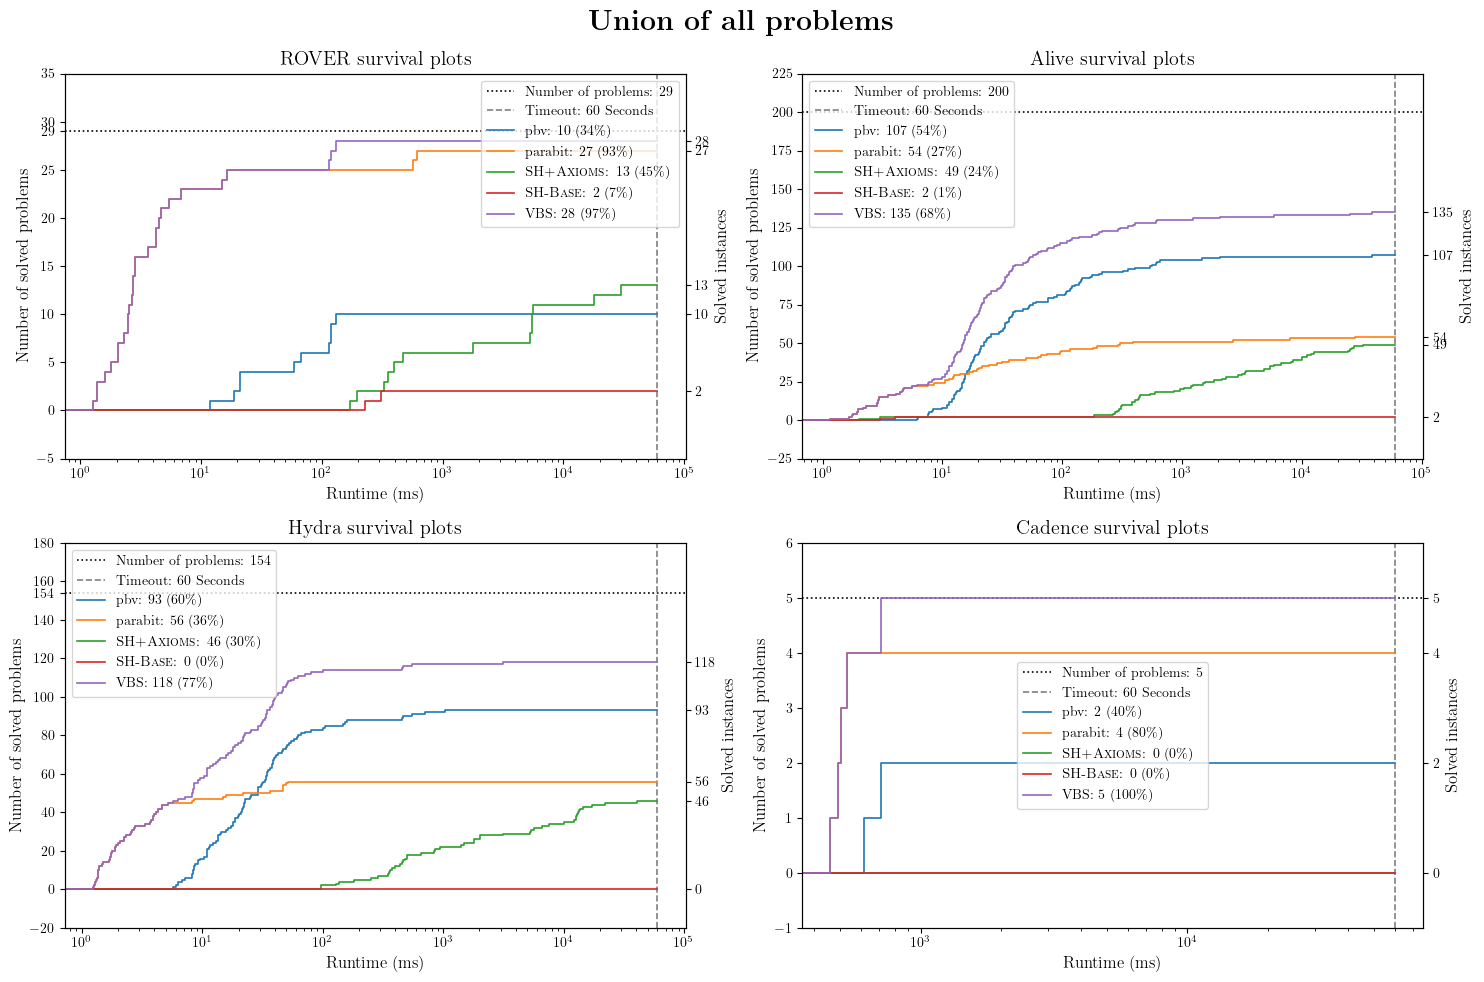

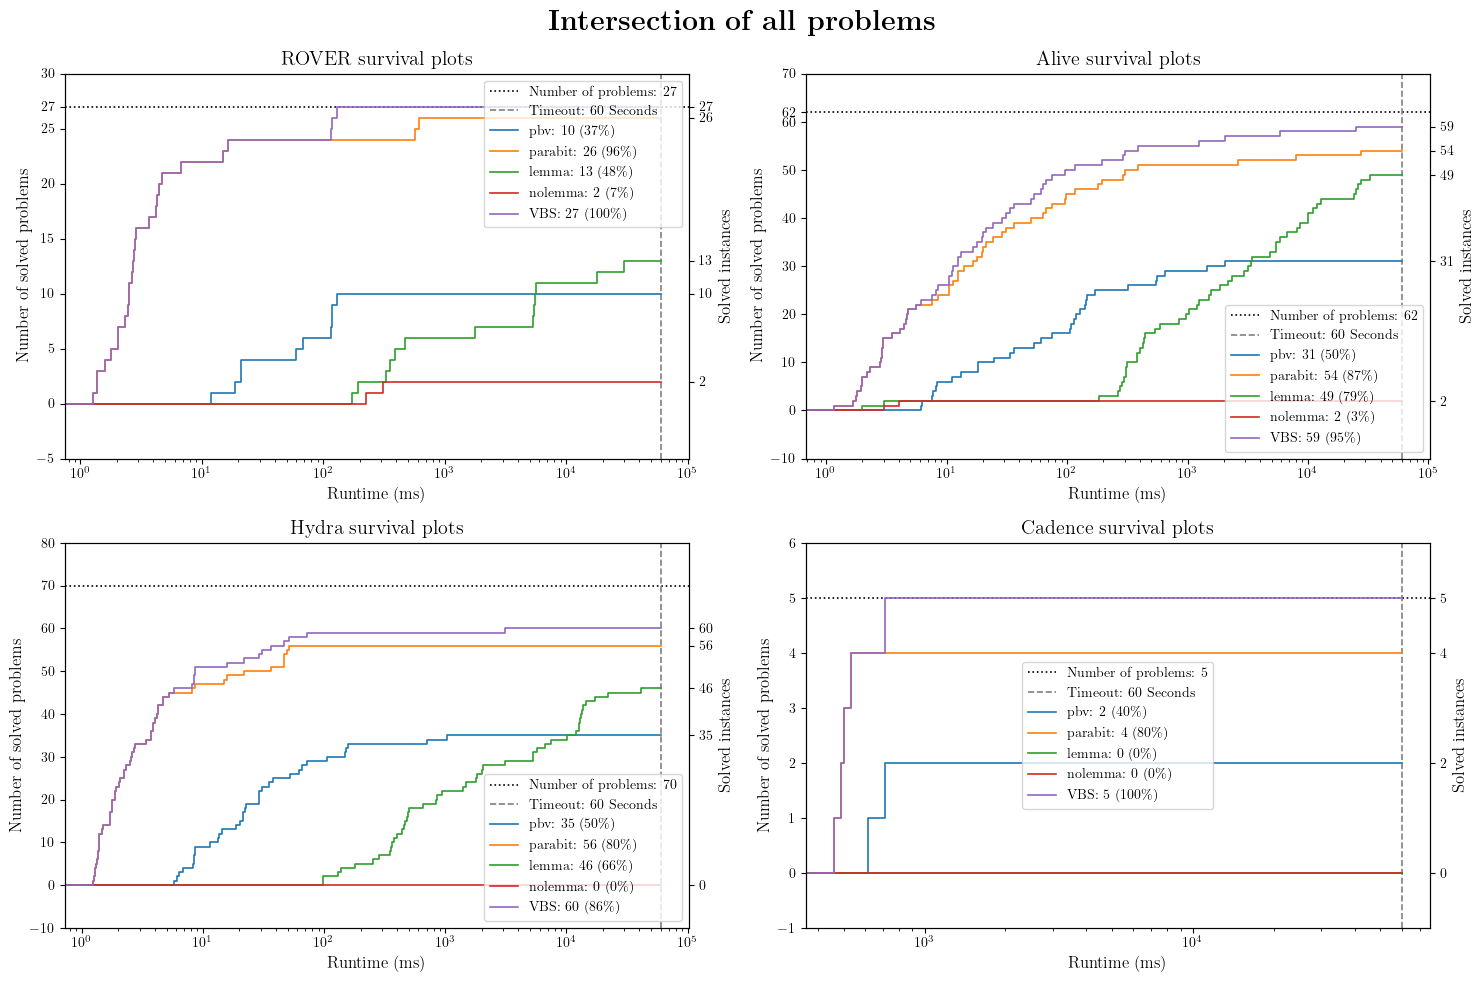

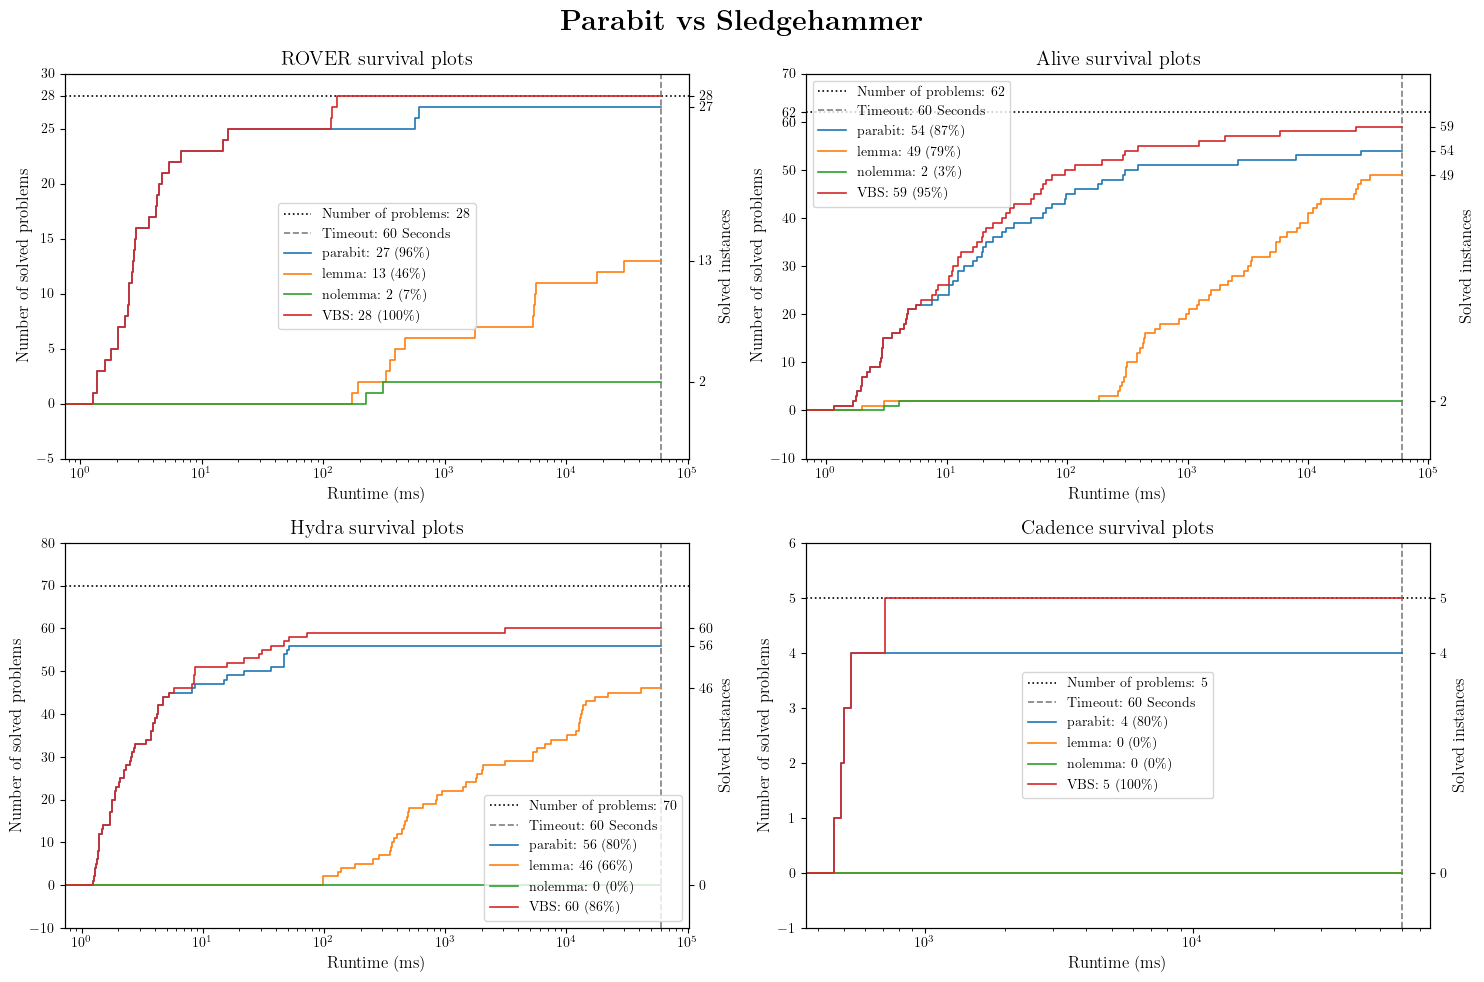

In [153]:

fig, axs = plt.subplots(2,2, figsize=(15,10))
for i, (bench, data) in enumerate(datas.items()):
    ax = axs[i%2][i//2]
    data_tmp = data.copy().drop(columns='name')
    data_tmp = data_tmp.rename(columns={'lemma':'\\textsc{SH+Axioms}', 'nolemma':'\\textsc{SH-Base}'})
    plot_cactus(ax, data_tmp, TIMEOUT)
    ax.legend(loc='best')
    ax.set_title(f'{bench} survival plots')
fig.suptitle('\\textbf{Union of all problems}', fontsize='xx-large')
plt.tight_layout()
# plt.savefig(f"{FIGURES_PATH}all_problem.pdf")
plt.show()

fig, axs = plt.subplots(2,2, figsize=(15,10))
for i, (bench, data) in enumerate(datas.items()):
    data_tmp = data.copy()
    
    filter_frame = data_tmp['name'].isin(parabit[bench]['file']) & data_tmp['name'].isin(pbv[bench]['file'])
    data_tmp = data_tmp[filter_frame].drop(columns='name')

    ax = axs[i%2][i//2]
    plot_cactus(ax, data_tmp, TIMEOUT)
    ax.legend(loc='best')
    ax.set_title(f'{bench} survival plots')
fig.suptitle('\\textbf{Intersection of all problems}', fontsize='xx-large')
plt.tight_layout()
# plt.savefig(f"{FIGURES_PATH}all_problem.pdf")
plt.show()


fig, axs = plt.subplots(2,2, figsize=(15,10))
for i, (bench, data) in enumerate(datas.items()):
    data_tmp = data.copy()
    
    filter_frame = data_tmp['name'].isin(parabit[bench]['file'])
    data_tmp = data_tmp[filter_frame].drop(columns=['name','pbv'])
    
    ax = axs[i%2][i//2]
    plot_cactus(ax, data_tmp, TIMEOUT)
    ax.legend(loc='best')
    ax.set_title(f'{bench} survival plots')
fig.suptitle('\\textbf{Parabit vs Sledgehammer}', fontsize='xx-large')
plt.tight_layout()
# plt.savefig(f"{FIGURES_PATH}all_problem.pdf")
plt.show()
